In [1]:
## TVSD MONKEYF 

In [2]:
def qwen_layer_order(layer_name):
    """Sort key respecting Qwen's vision→language hierarchy."""
    short = layer_name.split("/")[-1]
    if short.startswith("visual-blocks"):
        block_n = int(re.search(r"\d+", short).group())
        return (0, block_n)  # vision comes first
    elif short.startswith("language_model-layers"):
        layer_n = int(re.search(r"\d+", short).group())
        return (1, layer_n)  # language comes second
    else:
        return (2, short)    # fallback

def resnet_layer_order(layer_name):
    """Sort key for ResNet: layer1 < layer2 < layer3 < layer4, then by block."""
    short = layer_name.split("/")[-1]
    # e.g. "layer3-15" → ("layer", 3, 15)
    m = re.match(r"layer(\d+)-(\d+)", short)
    if m:
        return (int(m.group(1)), int(m.group(2)))
    return (99, short)

def order_layers(df, model_name):
    if "ResNet" in model_name:
        key_fn = resnet_layer_order
    elif "Qwen" in model_name:
        key_fn = qwen_layer_order
    else:
        key_fn = natkey
    sub = df[df["model"] == model_name].copy()
    sub["_order"] = sub["layer"].map(key_fn)
    return sub.sort_values("_order").drop(columns=["_order"]).reset_index(drop=True)

In [3]:
import pandas as pd

df_results = pd.read_csv("tvsd_monkeyf_v1_full_adam.csv")
df_results.head()

,dataset,model,layer,target,alpha,pearsonr,pearsonr_nc,explained_variance,explained_variance_nc,r_per_channel,ev_per_channel,r_nc_per_channel,ev_nc_per_channel,encoding_rsa,encoding_cka
0,TVSD,Model A (ResNet),features/layer1-0,monkeyF/V1,100000.0,0.793454,0.816754,0.512352,0.539221,[ 0.826278 0.71051395 0.91520864 0.901295...,[ 0.67520577 0.459701 0.836218 0.81...,[ 0.87668019 0.75045074 0.92638851 0.923668...,[ 0.76009204 0.51283141 0.85677268 0.85...,0.661866,0.859086
1,TVSD,Model A (ResNet),features/layer2-0,monkeyF/V1,100000.0,0.802218,0.825441,0.598908,0.629281,[ 0.7846653 0.7237385 0.9222504 0.900718...,[ 0.60979295 0.5038774 0.8495142 0.810489...,[ 0.83252917 0.76441861 0.93351628 0.923077...,[ 0.68645558 0.56211354 0.8703957 0.851227...,0.755375,0.891378
2,TVSD,Model A (ResNet),features/layer3-0,monkeyF/V1,100000.0,0.776880,0.799252,0.596166,0.627818,[0.80989325 0.737568 0.90721625 0.8928592 0...,[ 0.65426815 0.53062 0.8223977 0.792520...,[0.85929602 0.77902548 0.91829849 0.9150232 0...,[ 0.73652216 0.59194691 0.84261268 0.832355...,0.737942,0.870937
3,TVSD,Model A (ResNet),features/layer3-10,monkeyF/V1,100000.0,0.704085,0.723838,0.442265,0.461397,[ 0.81266224 0.69729316 0.8892574 0.867410...,[ 0.6557345 0.38134676 0.7829416 0.746512...,[ 0.86223392 0.73648683 0.90012023 0.888943...,[ 0.73817284 0.4254213 0.8021867 0.784035...,0.588682,0.785021
4,TVSD,Model A (ResNet),features/layer3-15,monkeyF/V1,100000.0,0.678825,0.697420,0.361906,0.372758,[ 0.56668884 0.6929096 0.8936858 0.861961...,[-5.90811014e-01 3.80824983e-01 7.83346534e-...,[ 0.60125635 0.73185688 0.90460278 0.883358...,[-6.65087251e-01 4.24839212e-01 8.02601609e-...,0.550934,0.759161


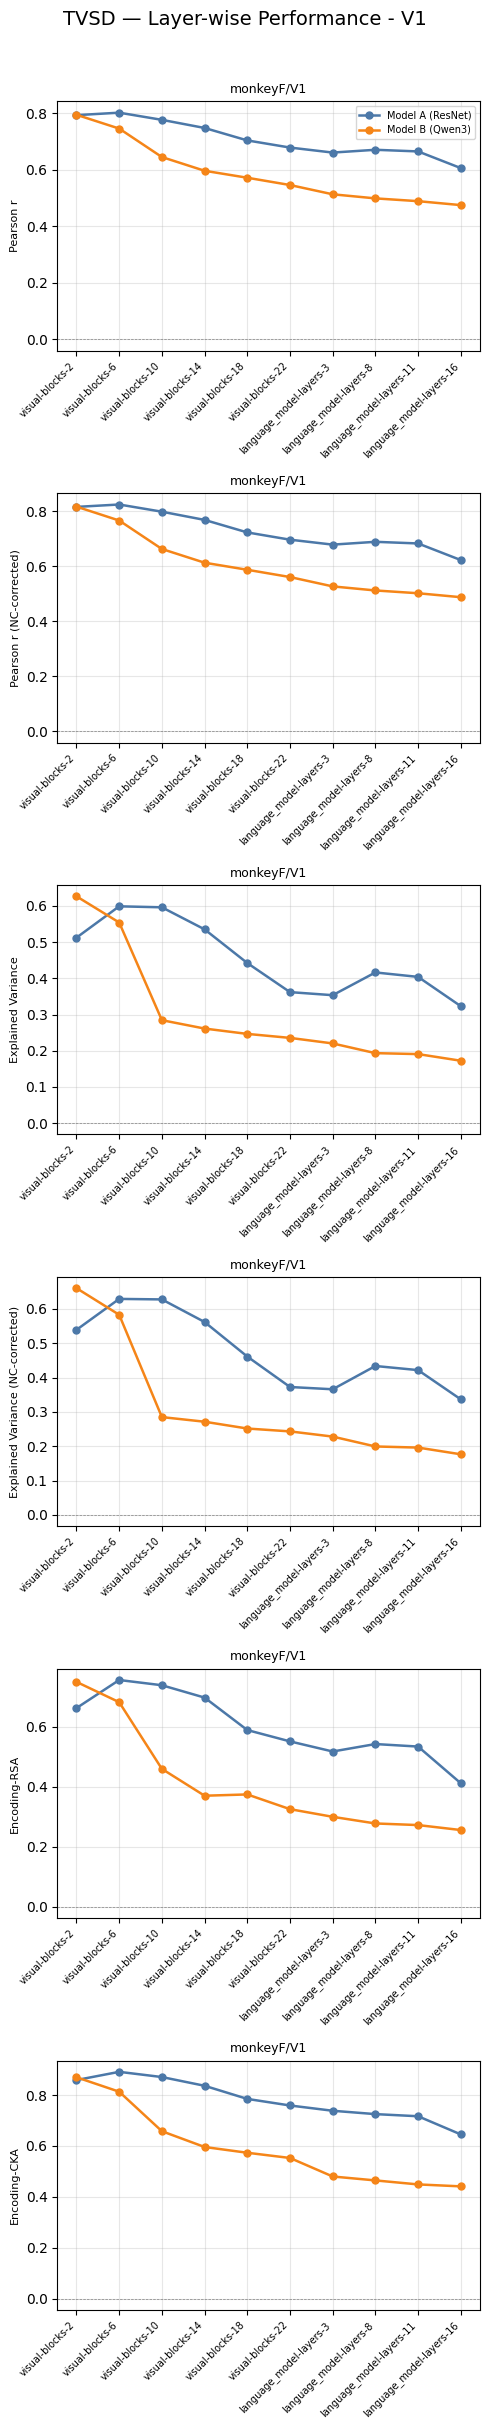

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
METRICS_TO_PLOT = [
    ("pearsonr",              "Pearson r"),
    ("pearsonr_nc",           "Pearson r (NC-corrected)"),
    ("explained_variance",    "Explained Variance"),
    ("explained_variance_nc", "Explained Variance (NC-corrected)"),
    ("encoding_rsa",          "Encoding-RSA"),
    ("encoding_cka",          "Encoding-CKA"),
]

for ds_name in df_results["dataset"].unique():
    sub_df  = df_results[df_results["dataset"] == ds_name]
    targets = sub_df["target"].unique()

    fig, axes = plt.subplots(
        len(METRICS_TO_PLOT), len(targets),
        figsize=(max(5, 4 * len(targets)), 4 * len(METRICS_TO_PLOT)),
        squeeze=False
    )
    fig.suptitle(f"{ds_name} — Layer-wise Performance - V1", fontsize=14, y=1.01)

    for row, (metric_key, metric_label) in enumerate(METRICS_TO_PLOT):
        for col, target in enumerate(targets):
            ax  = axes[row][col]
            tdf = sub_df[sub_df["target"] == target]

            for model, color in [("Model A (ResNet)", "#4c78a8"),
                                  ("Model B (Qwen3)",  "#f58518")]:
                mdf = order_layers(tdf, model)
                if mdf.empty:
                    continue
                x = np.arange(len(mdf))
                ax.plot(x, mdf[metric_key].values, marker="o",
                        label=model, color=color, linewidth=1.8, markersize=5)
                ax.set_xticks(x)
                ax.set_xticklabels(
                    [l.split("/")[-1] for l in mdf["layer"]],
                    rotation=45, ha="right", fontsize=7
                )

            ax.set_title(f"{target}", fontsize=9)
            if col == 0:
                ax.set_ylabel(metric_label, fontsize=8)
            ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")
            ax.grid(alpha=0.3)
            if row == 0 and col == 0:
                ax.legend(fontsize=7)

    plt.tight_layout()
    plt.show()


In [5]:
df_results = pd.read_csv("tvsd_monkeyf_v4_full_adam.csv")
df_results.head()

,dataset,model,layer,target,alpha,pearsonr,pearsonr_nc,explained_variance,explained_variance_nc,r_per_channel,ev_per_channel,r_nc_per_channel,ev_nc_per_channel,encoding_rsa,encoding_cka
0,TVSD,Model A (ResNet),features/layer1-0,monkeyF/V1,100000.0,0.793454,0.816754,0.512352,0.539221,[ 0.826278 0.71051395 0.91520864 0.901295...,[ 0.67520577 0.459701 0.836218 0.81...,[ 0.87668019 0.75045074 0.92638851 0.923668...,[ 0.76009204 0.51283141 0.85677268 0.85...,0.661866,0.859086
1,TVSD,Model A (ResNet),features/layer2-0,monkeyF/V1,100000.0,0.802218,0.825441,0.598908,0.629281,[ 0.7846653 0.7237385 0.9222504 0.900718...,[ 0.60979295 0.5038774 0.8495142 0.810489...,[ 0.83252917 0.76441861 0.93351628 0.923077...,[ 0.68645558 0.56211354 0.8703957 0.851227...,0.755375,0.891378
2,TVSD,Model A (ResNet),features/layer3-0,monkeyF/V1,100000.0,0.776880,0.799252,0.596166,0.627818,[0.80989325 0.737568 0.90721625 0.8928592 0...,[ 0.65426815 0.53062 0.8223977 0.792520...,[0.85929602 0.77902548 0.91829849 0.9150232 0...,[ 0.73652216 0.59194691 0.84261268 0.832355...,0.737942,0.870937
3,TVSD,Model A (ResNet),features/layer3-10,monkeyF/V1,100000.0,0.704085,0.723838,0.442265,0.461397,[ 0.81266224 0.69729316 0.8892574 0.867410...,[ 0.6557345 0.38134676 0.7829416 0.746512...,[ 0.86223392 0.73648683 0.90012023 0.888943...,[ 0.73817284 0.4254213 0.8021867 0.784035...,0.588682,0.785021
4,TVSD,Model A (ResNet),features/layer3-15,monkeyF/V1,100000.0,0.678825,0.697420,0.361906,0.372758,[ 0.56668884 0.6929096 0.8936858 0.861961...,[-5.90811014e-01 3.80824983e-01 7.83346534e-...,[ 0.60125635 0.73185688 0.90460278 0.883358...,[-6.65087251e-01 4.24839212e-01 8.02601609e-...,0.550934,0.759161


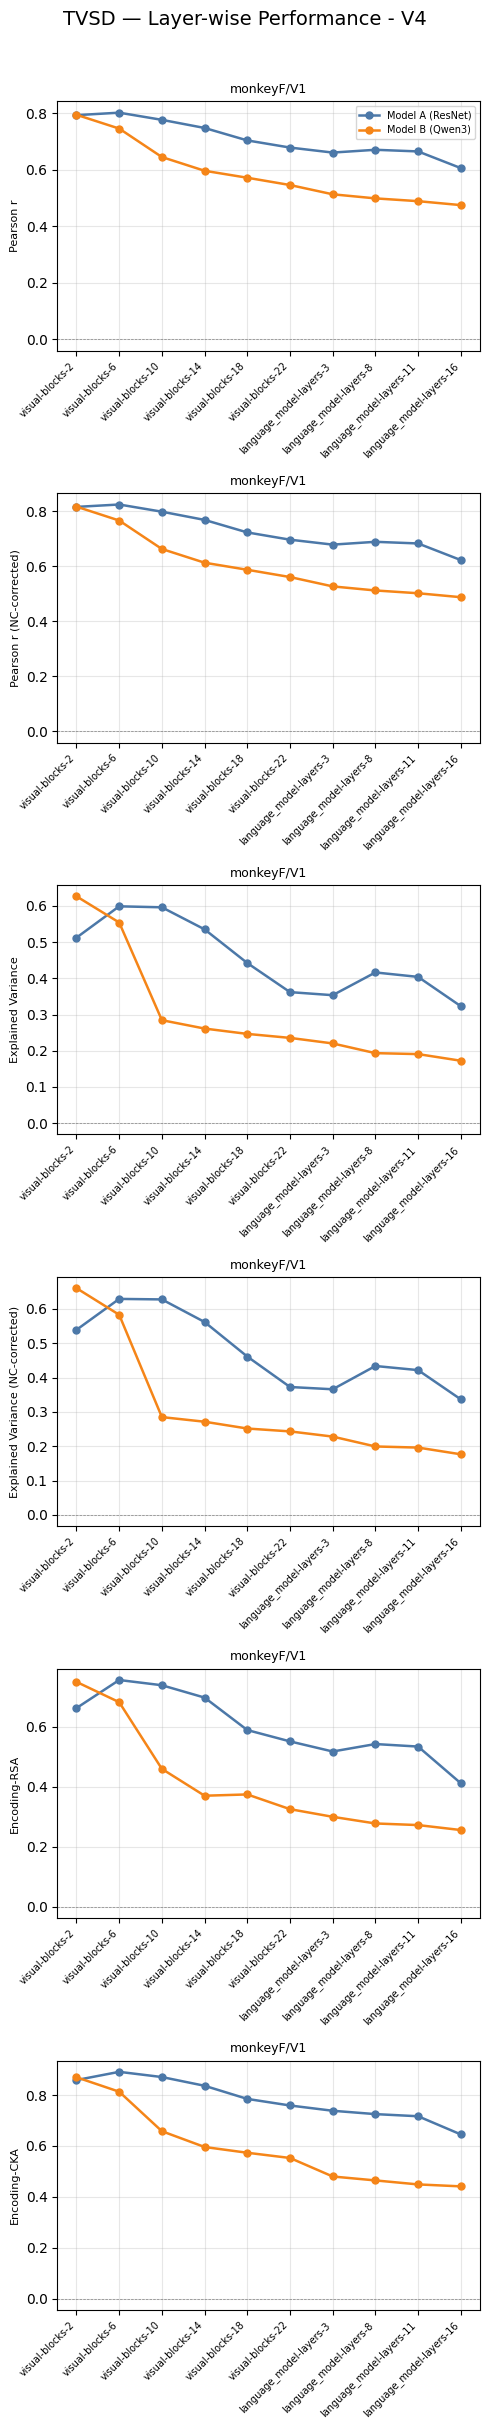

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
METRICS_TO_PLOT = [
    ("pearsonr",              "Pearson r"),
    ("pearsonr_nc",           "Pearson r (NC-corrected)"),
    ("explained_variance",    "Explained Variance"),
    ("explained_variance_nc", "Explained Variance (NC-corrected)"),
    ("encoding_rsa",          "Encoding-RSA"),
    ("encoding_cka",          "Encoding-CKA"),
]

for ds_name in df_results["dataset"].unique():
    sub_df  = df_results[df_results["dataset"] == ds_name]
    targets = sub_df["target"].unique()

    fig, axes = plt.subplots(
        len(METRICS_TO_PLOT), len(targets),
        figsize=(max(5, 4 * len(targets)), 4 * len(METRICS_TO_PLOT)),
        squeeze=False
    )
    fig.suptitle(f"{ds_name} — Layer-wise Performance - V4", fontsize=14, y=1.01)

    for row, (metric_key, metric_label) in enumerate(METRICS_TO_PLOT):
        for col, target in enumerate(targets):
            ax  = axes[row][col]
            tdf = sub_df[sub_df["target"] == target]

            for model, color in [("Model A (ResNet)", "#4c78a8"),
                                  ("Model B (Qwen3)",  "#f58518")]:
                mdf = order_layers(tdf, model)
                if mdf.empty:
                    continue
                x = np.arange(len(mdf))
                ax.plot(x, mdf[metric_key].values, marker="o",
                        label=model, color=color, linewidth=1.8, markersize=5)
                ax.set_xticks(x)
                ax.set_xticklabels(
                    [l.split("/")[-1] for l in mdf["layer"]],
                    rotation=45, ha="right", fontsize=7
                )

            ax.set_title(f"{target}", fontsize=9)
            if col == 0:
                ax.set_ylabel(metric_label, fontsize=8)
            ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")
            ax.grid(alpha=0.3)
            if row == 0 and col == 0:
                ax.legend(fontsize=7)

    plt.tight_layout()
    plt.show()


In [7]:
df_results = pd.read_csv("tvsd_monkeyf_it_full_adam.csv")
df_results.head()

,dataset,model,layer,target,alpha,pearsonr,pearsonr_nc,explained_variance,explained_variance_nc,r_per_channel,ev_per_channel,r_nc_per_channel,ev_nc_per_channel,encoding_rsa,encoding_cka
0,TVSD,Model A (ResNet),features/layer1-0,monkeyF/IT,100000.0,0.471020,0.487766,0.149456,0.152997,[0.4044529 0.05957298 0.20903708 0.16751756 0...,[ 1.39901936e-01 -1.42064810e-01 -2.67989635e-...,[0.40959568 0.06051984 0.21169476 0.17018562 0...,[ 1.43482378e-01 -1.46616653e-01 -2.74847345e-...,0.362994,0.324079
1,TVSD,Model A (ResNet),features/layer2-0,monkeyF/IT,100000.0,0.539177,0.558258,0.163605,0.167470,[0.3966818 0.11316807 0.35407537 0.29882064 0...,[ 1.35546386e-01 -1.14718318e-01 1.03598118e-...,[0.40172576 0.11496676 0.35857705 0.30357997 0...,[ 1.39015359e-01 -1.18393963e-01 1.06249137e-...,0.448783,0.410749
2,TVSD,Model A (ResNet),features/layer3-0,monkeyF/IT,100000.0,0.672344,0.696502,0.423599,0.450917,[0.4383091 0.3735729 0.5393078 0.4305282 0...,[ 0.16979891 0.08323735 0.2800038 0.058411...,[0.44388239 0.37951045 0.54616448 0.43738523 0...,[ 0.17414449 0.08590433 0.28716893 0.060287...,0.646586,0.638306
3,TVSD,Model A (ResNet),features/layer3-10,monkeyF/IT,100000.0,0.695303,0.720109,0.390486,0.411917,[0.49700484 0.46110734 0.60798603 0.5154932 0...,[ 0.22716379 0.15463161 0.3579046 0.123658...,[0.50332446 0.46843618 0.61571591 0.5237035 0...,[ 0.23297748 0.15958611 0.3670632 0.127628...,0.657392,0.682968
4,TVSD,Model A (ResNet),features/layer3-15,monkeyF/IT,100000.0,0.700996,0.725895,0.375515,0.392487,[0.5370761 0.5109798 0.64470977 0.55258036 0...,[ 0.25486565 0.20360321 0.39957607 0.160833...,[0.54390526 0.51910128 0.65290655 0.56138133 0...,[ 0.2613883 0.21012678 0.409801 0.165997...,0.692724,0.730191


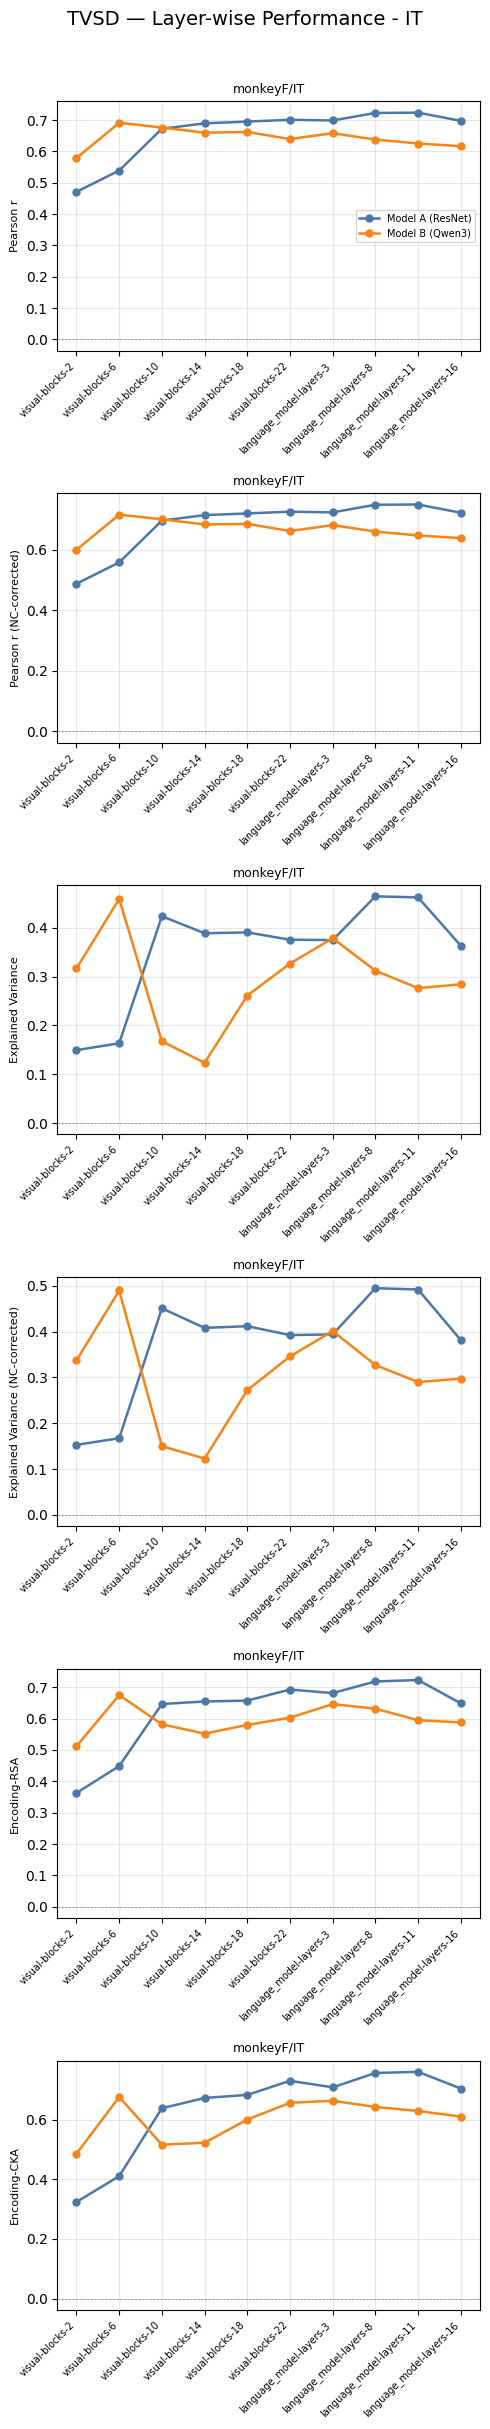

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
METRICS_TO_PLOT = [
    ("pearsonr",              "Pearson r"),
    ("pearsonr_nc",           "Pearson r (NC-corrected)"),
    ("explained_variance",    "Explained Variance"),
    ("explained_variance_nc", "Explained Variance (NC-corrected)"),
    ("encoding_rsa",          "Encoding-RSA"),
    ("encoding_cka",          "Encoding-CKA"),
]

for ds_name in df_results["dataset"].unique():
    sub_df  = df_results[df_results["dataset"] == ds_name]
    targets = sub_df["target"].unique()

    fig, axes = plt.subplots(
        len(METRICS_TO_PLOT), len(targets),
        figsize=(max(5, 4 * len(targets)), 4 * len(METRICS_TO_PLOT)),
        squeeze=False
    )
    fig.suptitle(f"{ds_name} — Layer-wise Performance - IT", fontsize=14, y=1.01)

    for row, (metric_key, metric_label) in enumerate(METRICS_TO_PLOT):
        for col, target in enumerate(targets):
            ax  = axes[row][col]
            tdf = sub_df[sub_df["target"] == target]

            for model, color in [("Model A (ResNet)", "#4c78a8"),
                                  ("Model B (Qwen3)",  "#f58518")]:
                mdf = order_layers(tdf, model)
                if mdf.empty:
                    continue
                x = np.arange(len(mdf))
                ax.plot(x, mdf[metric_key].values, marker="o",
                        label=model, color=color, linewidth=1.8, markersize=5)
                ax.set_xticks(x)
                ax.set_xticklabels(
                    [l.split("/")[-1] for l in mdf["layer"]],
                    rotation=45, ha="right", fontsize=7
                )

            ax.set_title(f"{target}", fontsize=9)
            if col == 0:
                ax.set_ylabel(metric_label, fontsize=8)
            ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")
            ax.grid(alpha=0.3)
            if row == 0 and col == 0:
                ax.legend(fontsize=7)

    plt.tight_layout()
    plt.show()
